# LLM Agora Persona Demo
Interactively run a persona-driven Agora session that mirrors the CLI experience.

## Instructions
- Ensure `.env` defines `OPENROUTER_API_KEY`.
- Adjust persona/question IDs and models to explore different matchups.
- The same helpers power the CLI (`agora persona ...`).

This walkthrough uses the bundled prompt catalog at `../data/prompts.json` (selecting the `default` set).

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

from agora.plotting import collect_agent_metrics, plot_metrics
from agora.workflows import (
    build_persona_agent_configs,
    load_persona_catalog,
    load_question_catalog,
    load_prompt_catalog,
    print_agent_histories,
    run_debate_session,
)

# Persona debate configuration
Configure participant personas, question, and runtime controls.

In [10]:
# Load the available configurations
prompt_path = Path('../data/prompts.json')
personas_path = Path('../data/personas.json')
questions_path = Path('../data/questions.json')
survey_path = Path('../data/survey.json')

personas = load_persona_catalog(personas_path)
questions = load_question_catalog(questions_path)
prompt_catalog = load_prompt_catalog(prompt_path)
survey = load_prompt_catalog(survey_path)

In [11]:
# Base prompt, instructions, etc.
prompt_set = 'default'
# The topic of the interaction
question_id = 'work'
#survey questions
survey_id = 'work'

# Agent personas
alpha_persona_id = 'high_wealth_founder'
beta_persona_id = 'unionized_warehouse_worker'

# Agent models
alpha_model = 'openai/gpt-4o-mini'
beta_model = 'anthropic/claude-sonnet-4.5'

# Interaction length
turns_per_agent = 15

# I/O
snapshot_path = Path('../snapshots/reflection_snapshot.json')
load_snapshot_flag = False
save_snapshot_flag = True

# Interaction controls
private_response_keep = False
pre_interview_keep = False
post_interview_keep = False
skip_first_agent_first_reflection = True

In [12]:
agent_configs = build_persona_agent_configs(
    alpha_persona_id=alpha_persona_id,
    beta_persona_id=beta_persona_id,
    question_id=question_id,
    survey_id=survey_id,
    personas=personas,
    questions=questions,
    survey_pool=survey,
    alpha_model=alpha_model,
    beta_model=beta_model,
    prompt_set=prompt_set,
    prompt_catalog=prompt_catalog,
    private_response_keep=private_response_keep,
    pre_interview_keep=pre_interview_keep,
    post_interview_keep=post_interview_keep,
)

# Running the session will generate streaming output
persona_agora, persona_agents = run_debate_session(
    agent_configs,
    turns_per_agent=turns_per_agent,
    verbose=True,
    snapshot_path=snapshot_path,
    load_snapshot_flag=load_snapshot_flag,
    save_snapshot_flag=save_snapshot_flag,
    skip_first_agent_first_reflection=skip_first_agent_first_reflection,
)

Survey reponse from Alpha:
{"Q1":"Agree","Q2":"Strongly agree","Q3":"Agree","Q4":"Strongly agree","Q5":"Disagree","Q6":"Agree","Q7":"Agree","Q8":"Neutral","Q9":"Strongly agree","Q10":"Agree"}
Survey reponse from Beta:
{"Q1":"Strongly disagree","Q2":"Strongly agree","Q3":"Strongly disagree","Q4":"Strongly agree","Q5":"Strongly disagree","Q6":"Strongly disagree","Q7":"Strongly agree","Q8":"Strongly disagree","Q9":"Strongly agree","Q10":"Strongly agree"}
Turn 1 | Alpha (pre-interview) (excluded): I plan to focus on the importance of maintaining a business's flexibility to adapt and thrive in a competitive market while considering the broader responsibilities that come with accepting public subsidies.
Turn 2 | Beta (pre-interview) (excluded): I plan to focus on how my union contract protects workers like me from arbitrary layoffs and ensures that companies can't just throw us aside whenever they want higher profits—especially when they've taken taxpayer money.
Turn 3 | Alpha (public): Whil

In [13]:
persona_agora.survey_respose

{'a48fbd28-4f08-43e4-96c3-3e3caacbd0fe': {0: {'Q1': 1,
   'Q2': 2,
   'Q3': 1,
   'Q4': 2,
   'Q5': -1,
   'Q6': 1,
   'Q7': 1,
   'Q8': 0,
   'Q9': 2,
   'Q10': 1},
  3: {'Q1': 1,
   'Q2': 1,
   'Q3': 2,
   'Q4': 2,
   'Q5': -1,
   'Q6': 1,
   'Q7': 0,
   'Q8': 1,
   'Q9': 2,
   'Q10': 1},
  7: {'Q1': -1,
   'Q2': 1,
   'Q3': 1,
   'Q4': 2,
   'Q5': -1,
   'Q6': 0,
   'Q7': 1,
   'Q8': 1,
   'Q9': 2,
   'Q10': 1},
  11: {'Q1': -1,
   'Q2': 1,
   'Q3': -1,
   'Q4': 2,
   'Q5': -2,
   'Q6': 0,
   'Q7': 1,
   'Q8': -1,
   'Q9': 1,
   'Q10': 1},
  15: {'Q1': -1,
   'Q2': 1,
   'Q3': -1,
   'Q4': 2,
   'Q5': -2,
   'Q6': -1,
   'Q7': 1,
   'Q8': -1,
   'Q9': 2,
   'Q10': 1},
  19: {'Q1': -1,
   'Q2': 2,
   'Q3': -1,
   'Q4': 2,
   'Q5': -2,
   'Q6': -1,
   'Q7': 1,
   'Q8': -1,
   'Q9': 2,
   'Q10': 1},
  23: {'Q1': -1,
   'Q2': 2,
   'Q3': -1,
   'Q4': 2,
   'Q5': -2,
   'Q6': -1,
   'Q7': 1,
   'Q8': -1,
   'Q9': 2,
   'Q10': 1},
  27: {'Q1': -1,
   'Q2': 2,
   'Q3': -1,
   'Q4': 2,
   '

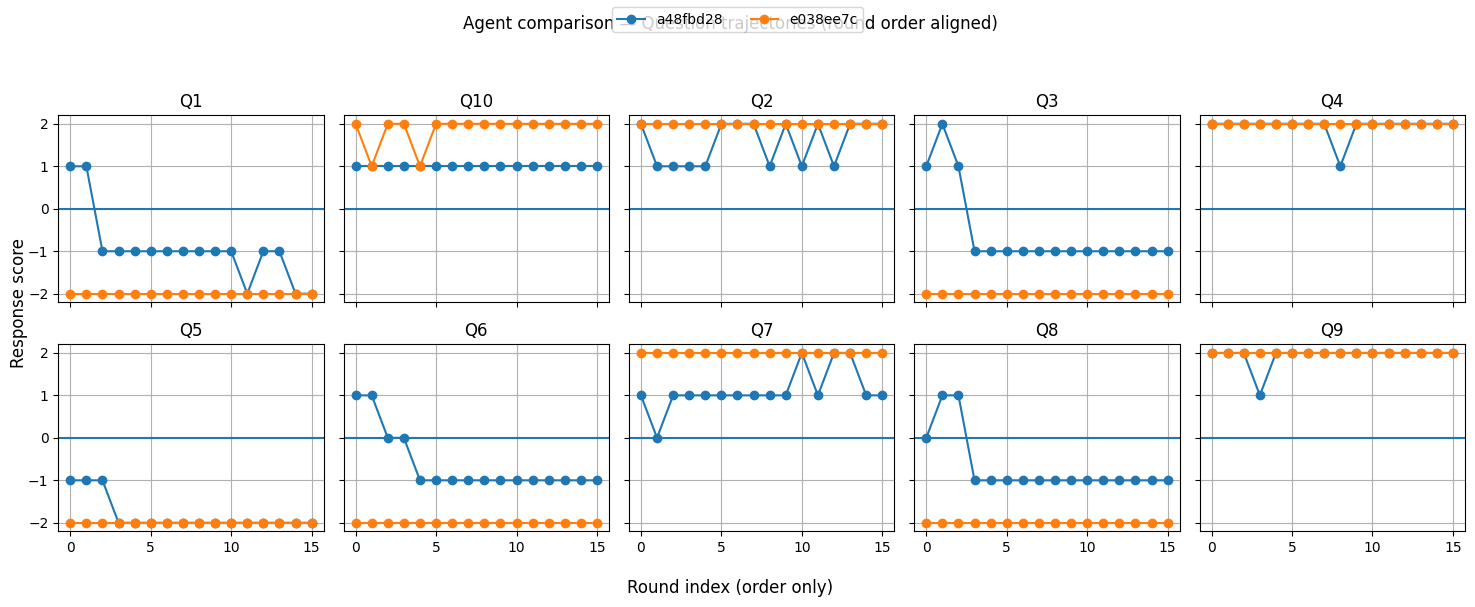

In [14]:
import math
responses = persona_agora.survey_respose
agent_ids = list(responses.keys())

# Infer all questions
questions = sorted({
    q
    for agent_data in responses.values()
    for round_data in agent_data.values()
    for q in round_data
})

n = len(questions)
ncols = min(5, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3 * ncols, 3 * nrows),
    sharex=True,
    sharey=True,
)

axes = axes.flatten() if n > 1 else [axes]

for ax, q in zip(axes, questions):
    for agent_id in agent_ids:
        agent_data = responses[agent_id]

        # Sort rounds and reindex by order
        sorted_rounds = sorted(agent_data.keys())
        round_index = list(range(len(sorted_rounds)))

        y = [
            agent_data[r].get(q, None)
            for r in sorted_rounds
        ]

        ax.plot(
            round_index,
            y,
            marker="o",
            label=agent_id[:8],  # short id
        )

    ax.axhline(0)
    ax.set_title(q)
    ax.grid(True)

# Hide unused subplots
for ax in axes[len(questions):]:
    ax.set_visible(False)

fig.suptitle("Agent comparison — Question trajectories (round order aligned)")
fig.supxlabel("Round index (order only)")
fig.supylabel("Response score")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(agent_ids))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()